In [ ]:
# Ein Credit Score (Bonitätsscore) ist ein Zahlenwert (typisch 300–850 in den USA, oft prozentual in Deutschland (Schufa))
# Ein höherer Wert bedeutet ein geringeres Risiko für Banken und bessere Konditionen.
# Er wird primär durch Zahlungshistorie + Kreditauslastung + Kredithistorie + Kreditmix + Neue Kredit Anfrage beeinflusst.

# Weight of Evidence (WOE) encoding, typically in binary classification problems like credit scoring.
# It transforms continuous or categorical variables into a numerical format that represents their relationship with a
# target variable (0/1).

# The Kolmogorov–Smirnov (KS) test - a non-parametric method for comparing probability distributions and checking if two samples differ significantly.
# It is widely used in statistics, data analysis and quality control because it does not assume any specific distribution form.
# Compares one-dimensional distributions without assuming a specific form.
# Often used to test random number uniformity or model fit.
# Provides a statistic and p-value to determine if samples differ significantly.

# Ada Boost - a statistical classification meta-algorithm formulated by Yoav Freund and Robert Schapire in 1995
# AdaBoost refers to a particular method of training a boosted classifier
# Technique that combines several weak classifiers in sequence to build a strong one: XGBoostl, CatBoost, Gradient Boosting, ...

In [ ]:
pip install optuna

In [ ]:
pip install catboost

In [3]:
from matplotlib import pyplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
from sklearn import metrics
import plotly.express as ex
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.offline as pyo
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import  OneHotEncoder
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import optuna
import xgboost as xgb
import lightgbm as lgb
import catboost as cat

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Explortory Data Analytics

In [4]:
data = pd.read_csv('credit_scorecard.csv')

In [5]:
data.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,25,72000,MORTGAGE,NaN,HOMEIMPROVEMENT,A,2000,7.66,0,0.03,N,4
1,26,32000,RENT,4.0,DEBTCONSOLIDATION,A,12250,NaN,1,0.38,N,2
2,25,34000,MORTGAGE,2.0,HOMEIMPROVEMENT,C,5800,13.48,1,0.17,Y,3
3,25,118000,MORTGAGE,8.0,HOMEIMPROVEMENT,A,15000,7.88,0,0.13,N,4
4,22,96000,MORTGAGE,6.0,EDUCATION,C,6000,13.49,0,0.06,N,3


In [6]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,19881.000000,1.988100e+04,19335.000000,19881.000000,17971.000000,19881.000000,19881.000000,19881.000000
mean,27.710025,6.623181e+04,4.784432,9600.399879,11.016532,0.217796,0.170032,5.790755
std,6.332000,6.728205e+04,4.047749,6339.463522,3.245504,0.412758,0.107037,4.048260
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.860400e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.900000e+04,7.000000,12250.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19881 entries, 0 to 19880
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  19881 non-null  int64  
 1   person_income               19881 non-null  int64  
 2   person_home_ownership       19881 non-null  object 
 3   person_emp_length           19335 non-null  float64
 4   loan_intent                 19881 non-null  object 
 5   loan_grade                  19881 non-null  object 
 6   loan_amnt                   19881 non-null  int64  
 7   loan_int_rate               17971 non-null  float64
 8   loan_status                 19881 non-null  int64  
 9   loan_percent_income         19881 non-null  float64
 10  cb_person_default_on_file   19881 non-null  object 
 11  cb_person_cred_hist_length  19881 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 1.8+ MB


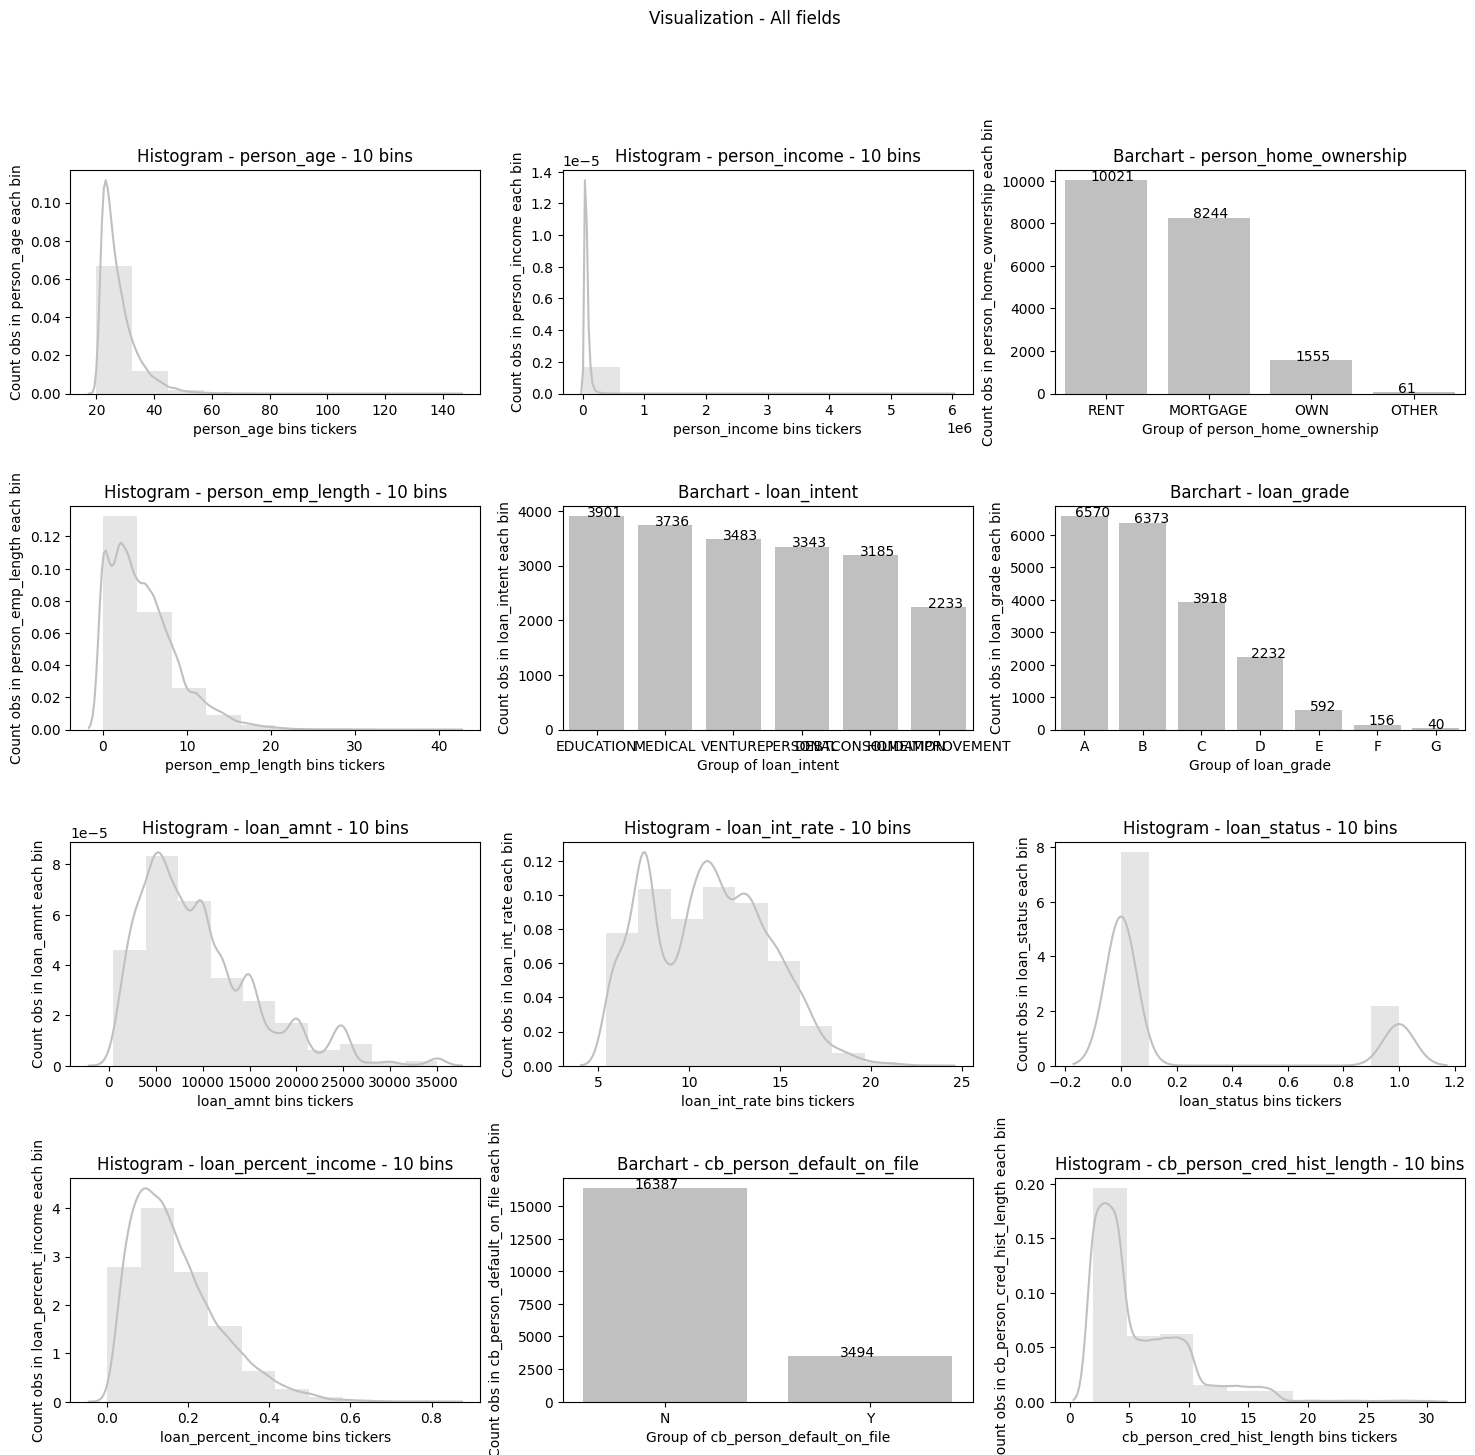

In [8]:
# kde=True: (Default) Shows both the histogram and the smooth KDE curve.
# Kernel Density Estimation (KDE) plot—a smooth curve representing the data distribution

def _plot_hist_subplot(x, fieldname, bins = 10, use_kde = True):
    x = x.dropna()
    xlabel = '{} bins tickers'.format(fieldname)
    ylabel = 'Count obs in {} each bin'.format(fieldname)
    title = 'Histogram - {} - {} bins'.format(fieldname, bins)
    ax = sns.distplot(x, bins = bins, kde = use_kde, color='silver')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    return ax

# obs - observations count in each bin
def _plot_barchart_subplot(x, fieldname):
    xlabel = 'Group of {}'.format(fieldname)
    ylabel = 'Count obs in {} each bin'.format(fieldname)
    title = 'Barchart - {}'.format(fieldname)
    x = x.fillna('Missing')
    df_summary = x.value_counts(dropna = False)
    y_values = df_summary.values
    x_index = df_summary.index
    ax = sns.barplot(x = x_index, y = y_values, order = x_index, color='silver')

    labels = list(set(x))
    for label, p in zip(y_values, ax.patches):
        ax.annotate(label, (p.get_x()+0.25, p.get_height()+0.15))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    return ax


fig = plt.figure(figsize=(18, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)

for i, (fieldname, dtype) in enumerate(zip(data.columns, data.dtypes.values)):
    if i <= 11:
        ax_i = fig.add_subplot(4, 3, i+1)
        if dtype in ['float64', 'int64']:
            ax_i = _plot_hist_subplot(data[fieldname], fieldname=fieldname)
        else:
            ax_i = _plot_barchart_subplot(data[fieldname], fieldname=fieldname)
fig.suptitle('Visualization - All fields')
plt.show()

In [9]:
ex.pie(data,
       names='loan_status',
       title='Propotion Of Loan Status',
       hole=0.33,
       color_discrete_sequence=ex.colors.sequential.Greys_r
       )

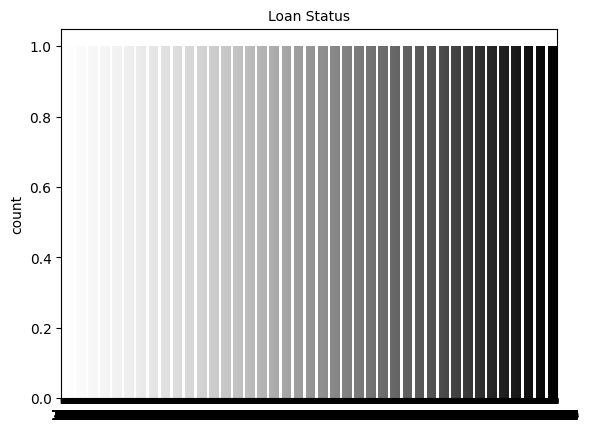

In [10]:
sns.countplot(data["loan_status"], palette='Greys')
plt.title("Loan Status",fontsize=10)
plt.show()

In [11]:
ex.pie(data,
       names='person_home_ownership',
       title='Propotion Of Person Home Ownership',
       hole=0.33,
       color_discrete_sequence=ex.colors.sequential.Greys_r
       )

In [12]:
ex.pie(data,
       names='loan_intent',
       title='Propotion Of Loan Intent',
       hole=0.33,
       color_discrete_sequence=ex.colors.sequential.Greys_r
       )

In [13]:
ex.pie(data,names='loan_grade',
       title='Propotion Of Loan Grade',
       hole=0.33,
       color_discrete_sequence=ex.colors.sequential.Greys_r
       )

In [14]:
ex.pie(data,names='cb_person_default_on_file',
       title='Propotion Of CB Person Default On File',
       hole=0.33,
       #color_discrete_sequence=ex.colors.qualitative.Set3
       color_discrete_sequence=ex.colors.sequential.Greys_r
       )

<Axes: xlabel='cb_person_default_on_file', ylabel='count'>

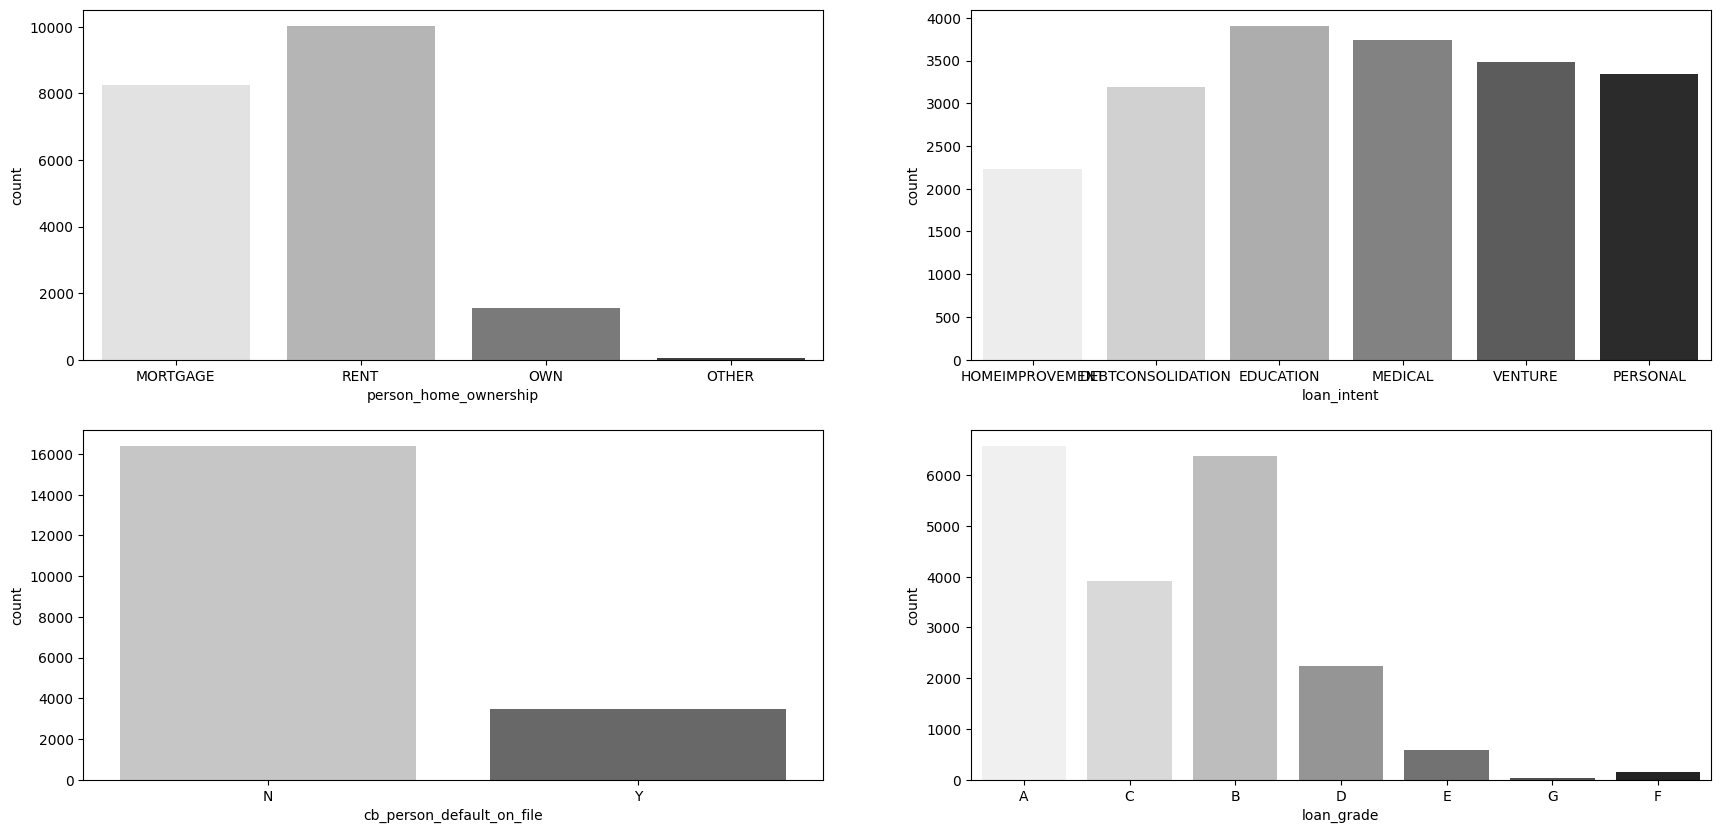

In [15]:
fig,axes = plt.subplots(2,2, figsize=(21,10))

sns.countplot(x='person_home_ownership',data=data,ax=axes[0,0],palette='Greys')
sns.countplot(x='loan_intent',data=data,ax=axes[0,1],palette='Greys')
sns.countplot(x='loan_grade',data=data,ax=axes[1,1],palette='Greys')
sns.countplot(x='cb_person_default_on_file',data=data,ax=axes[1,0],palette='Greys')

<Axes: xlabel='cb_person_default_on_file', ylabel='count'>

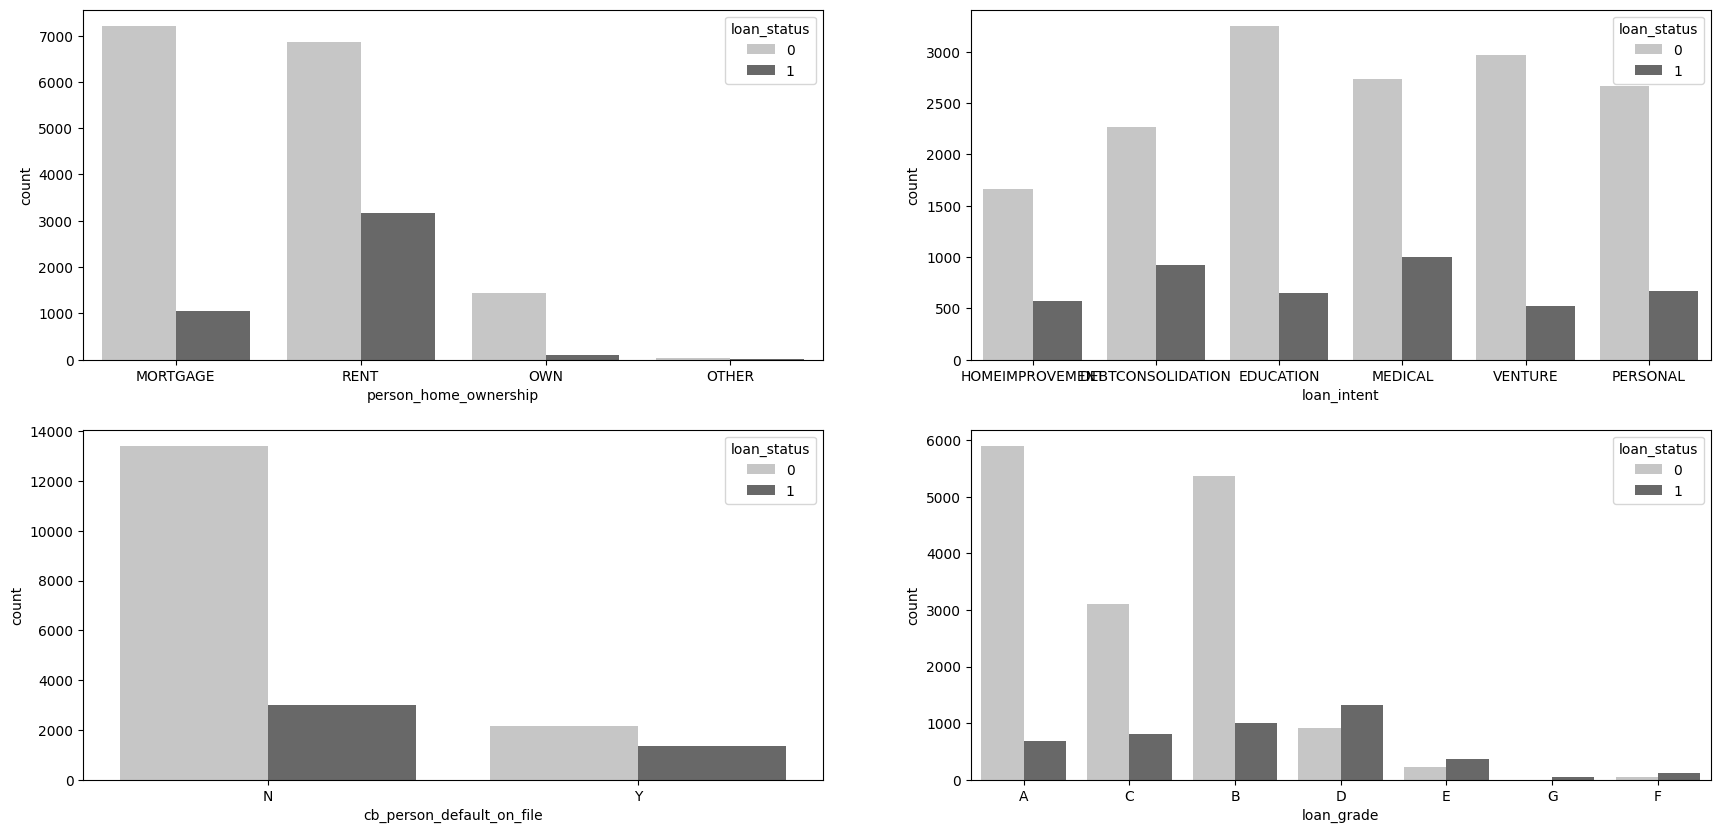

In [16]:
fig,axes = plt.subplots(2,2, figsize=(21,10))

sns.countplot(x='person_home_ownership',hue="loan_status",data=data,ax=axes[0,0],palette='Greys')
sns.countplot(x='loan_intent',data=data,hue="loan_status",ax=axes[0,1],palette='Greys')
sns.countplot(x='loan_grade',data=data,hue="loan_status",ax=axes[1,1],palette='Greys')
sns.countplot(x='cb_person_default_on_file',hue="loan_status",data=data,ax=axes[1,0],palette='Greys')

In [ ]:
# Data Preprocesing

In [17]:
def missing_zero_values_table(df):
        zero_val = (df == 0.00).astype(int).sum(axis=0)
        mis_val = df.isnull().sum()
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        mz_table = pd.concat([zero_val, mis_val, mis_val_percent], axis=1)
        mz_table = mz_table.rename(
        columns = {0 : 'Zero Values', 1 : 'Missing Values', 2 : '% of Total Values'})
        mz_table['Total Zero Missing Values'] = mz_table['Zero Values'] + mz_table['Missing Values']
        mz_table['% Total Zero Missing Values'] = 100 * mz_table['Total Zero Missing Values'] / len(df)
        mz_table['Data Type'] = df.dtypes
        mz_table = mz_table[
            mz_table.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns and " + str(df.shape[0]) + " Rows.\n"
            "There are " + str(mz_table.shape[0]) +
              " columns that have missing values.")
        return mz_table

missing_zero_values_table(data)

Your selected dataframe has 12 columns and 19881 Rows.
There are 2 columns that have missing values.


,Zero Values,Missing Values,% of Total Values,Total Zero Missing Values,% Total Zero Missing Values,Data Type
loan_int_rate,0,1910,9.6,1910,9.6,float64
person_emp_length,2532,546,2.7,3078,15.5,float64


In [18]:
columns_num = data.select_dtypes(['float', 'int']).columns
data[columns_num] = data[columns_num].apply(lambda x: x.fillna(x.mean()), axis=0)

In [19]:
columns_obj = data.select_dtypes(['object']).columns
data[columns_obj] = data[columns_obj].apply(lambda x: x.fillna('Missing'), axis=0)

In [ ]:
# Calculate WOE (Weight of Evidence) for each feature

In [20]:
import numpy as np
import matplotlib.pyplot as plt

MAX_VAL = 999999999
MIN_VAL = -MAX_VAL

# qcut - dividing a continuous variable into quantile-based bins
# retbins - Passing retbins as True returns the bin boundaries

def _bin_table(data, colname, n_bins = 10, qcut = None):
  X = data[[colname, 'loan_status']]
  X = X.sort_values(colname)
  coltype = X[colname].dtype

  if coltype in ['float', 'int']:
    if qcut is None:
      try:
        bins, thres = pd.qcut(X[colname], q = n_bins, retbins=True)

        thres[0] = MIN_VAL
        thres[-1] = MAX_VAL
        bins, thres = pd.cut(X[colname], bins=thres, retbins=True)
        X['bins'] = bins
      except:
        print('n_bins must be lower to bin interval is valid!')
    else:
      bins, thres = pd.cut(X[colname], bins=qcut, retbins=True)
      X['bins'] = bins
  elif coltype == 'object':
    X['bins'] = X[colname]

  df_GB = pd.pivot_table(X,
                index = ['bins'],
                values = ['loan_status'],
                columns = ['loan_status'],
                aggfunc = {
                    'loan_status':np.size
                })

  df_Count = pd.pivot_table(X,
                index = ['bins'],
                values = ['loan_status'],
                aggfunc = {
                    'loan_status': np.size
                })

  if coltype in ['float', 'int']:
    df_Thres = pd.DataFrame({'Thres':thres[1:]}, index=df_GB.index)
  elif coltype == 'object':
    df_Thres = pd.DataFrame(index=df_GB.index)
    thres = None
  df_Count.columns = ['No_Obs']
  df_GB.columns = ['#BAD', '#GOOD']
  df_summary = df_Thres.join(df_Count).join(df_GB)
  return df_summary, thres

In [22]:
# split to bins for float columns
#df_summary, thres = _bin_table(data, 'loan_percent_income', n_bins=5)
df_summary, thres = _bin_table(data, 'loan_int_rate', n_bins=5)
df_summary

,Thres,No_Obs,#BAD,#GOOD
bins,,,,
"(-999999999.0, 7.74]",7.740000e+00,3982,3632,350
"(7.74, 10.62]",1.062000e+01,4094,3503,591
"(10.62, 11.49]",1.149000e+01,4047,3321,726
"(11.49, 13.61]",1.361000e+01,3834,3085,749
"(13.61, 999999999.0]",1.000000e+09,3924,2010,1914


In [23]:
# Define WOE (Weight of Evidence)

def _WOE(data, colname, n_bins = None, min_obs = 100, qcut = None):

  df_summary, thres = _bin_table(data, colname, n_bins = n_bins, qcut = qcut)

  df_summary['#BAD'] = df_summary['#BAD'].replace({0:1})

  if qcut is not None:

    exclude_ind = np.where(df_summary['No_Obs'] <= min_obs)[0]
    if exclude_ind.shape[0] > 0:
      new_thres = np.delete(thres, exclude_ind)
      print('Auto combine {} bins into {} bins'.format(n_bins, new_thres.shape[0]-1))

      df_summary, thres = _bin_table(data, colname, qcut=new_thres)

  new_thres = thres
  df_summary['GOOD/BAD'] = df_summary['#GOOD']/df_summary['#BAD']
  df_summary['%BAD'] = df_summary['#BAD']/df_summary['#BAD'].sum()
  df_summary['%GOOD'] = df_summary['#GOOD']/df_summary['#GOOD'].sum()
  df_summary['WOE'] = np.log(df_summary['%GOOD']/df_summary['%BAD'])
  df_summary['IV'] = (df_summary['%GOOD']-df_summary['%BAD'])*df_summary['WOE']
  df_summary['COLUMN'] = colname
  IV = df_summary['IV'].sum()
  print('Information Value of {} column: {}'.format(colname, IV))
  return df_summary, IV, new_thres

df_summary, IV, thres = _WOE(data, 'loan_percent_income', n_bins = 7, min_obs= 100)
df_summary

Information Value of loan_percent_income column: 0.8814234539254481


,Thres,No_Obs,#BAD,#GOOD,GOOD/BAD,%BAD,%GOOD,WOE,IV,COLUMN
bins,,,,,,,,,,
"(-999999999.0, 0.06]",6.000000e-02,2895,2599,296,0.113890,0.167128,0.068360,-0.893965,0.088294,loan_percent_income
"(0.06, 0.1]",1.000000e-01,3530,3059,471,0.153972,0.196708,0.108776,-0.592428,0.052093,loan_percent_income
"(0.1, 0.13]",1.300000e-01,2530,2228,302,0.135548,0.143271,0.069746,-0.719875,0.052929,loan_percent_income
"(0.13, 0.17]",1.700000e-01,3056,2587,469,0.181291,0.166356,0.108314,-0.429094,0.024905,loan_percent_income
"(0.17, 0.21]",2.100000e-01,2304,1890,414,0.219048,0.121536,0.095612,-0.239909,0.006219,loan_percent_income
"(0.21, 0.29]",2.900000e-01,2941,2288,653,0.285402,0.147129,0.150808,0.024701,0.000091,loan_percent_income
"(0.29, 999999999.0]",1.000000e+09,2625,900,1725,1.916667,0.057874,0.398383,1.929145,0.656892,loan_percent_income


In [ ]:
# Plot the WOE of bins value for each feature

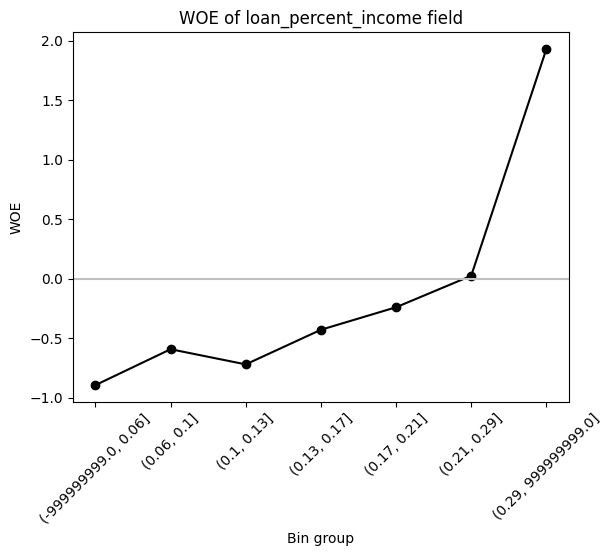

In [24]:
def _plot(df_summary):
    colname = list(df_summary['COLUMN'].unique())[0]
    df_summary['WOE'].plot(linestyle='-', marker='o', color='black')
    plt.title('WOE of {} field'.format(colname))
    plt.axhline(y=0, color = 'silver')
    plt.xticks(rotation=45)
    plt.ylabel('WOE')
    plt.xlabel('Bin group')

_plot(df_summary)

In [ ]:
# Calculate WOE for all features

In [25]:

WOE_dict=dict()
nbins = {'person_age': 10, 'person_income': 10, 'person_emp_length': 5, 'loan_amnt':10, 'loan_int_rate':10, 'cb_person_cred_hist_length': 5, 'loan_percent_income':10}
for (col, bins) in nbins.items():
    df_summary, IV, thres = _WOE(data, colname=col, n_bins=bins)
    WOE_dict[col] = {'table':df_summary, 'IV':IV}

Information Value of person_age column: 0.017560813711781354
Information Value of person_income column: 0.4827249034688532
Information Value of person_emp_length column: 0.0468335476752727
Information Value of loan_amnt column: 0.08505991048842812
Information Value of loan_int_rate column: 0.6489219359673384
Information Value of cb_person_cred_hist_length column: 0.00529779175767272
Information Value of loan_percent_income column: 0.8794480283574145


In [29]:
for col in ['person_home_ownership', 'loan_intent','loan_grade',
           'cb_person_default_on_file']:
    df_summary, IV, thres = _WOE(data, colname=col)
    WOE_dict[col] = {'table':df_summary, 'IV':IV}

Information Value of person_home_ownership column: 0.38388310123715347
Information Value of loan_intent column: 0.09896966582526268
Information Value of loan_grade column: 0.8758727476776351
Information Value of cb_person_default_on_file column: 0.17409066245127763


In [ ]:
# Rank the features by the IV

In [30]:
columns = []
IVs = []
for col in data.columns:
    if col != 'loan_status':
        columns.append(col)
        IVs.append(WOE_dict[col]['IV'])
df_WOE = pd.DataFrame({'column': columns, 'IV': IVs})

def _rank_IV(iv):
      if iv <= 0.02:
        return 'Useless'
      elif iv <= 0.1:
        return 'Weak'
      elif iv <= 0.3:
        return 'Medium'
      elif iv <= 0.5:
        return 'Strong'
      else:
        return 'suspicious'

df_WOE['rank']=df_WOE['IV'].apply(lambda x: _rank_IV(x))
df_WOE.sort_values('IV', ascending=False)

,column,IV,rank
8,loan_percent_income,0.879448,suspicious
5,loan_grade,0.875873,suspicious
7,loan_int_rate,0.648922,suspicious
1,person_income,0.482725,Strong
2,person_home_ownership,0.383883,Strong
9,cb_person_default_on_file,0.174091,Medium
4,loan_intent,0.098970,Weak
6,loan_amnt,0.085060,Weak
3,person_emp_length,0.046834,Weak
0,person_age,0.017561,Useless


In [ ]:
# Logistic Model

In [ ]:
# Map bins with WOE value

In [31]:
for col in WOE_dict.keys():
    try:
        key = list(WOE_dict[col]['table']['WOE'].index)
        woe = list(WOE_dict[col]['table']['WOE'])
        d = dict(zip(key, woe))
        col_woe = col+'_WOE'
        data[col_woe] = data[col].map(d)
    except:
        print(col)

In [32]:
X = data.filter(like='_WOE', axis = 1)
y = data['loan_status']

In [33]:
X

,person_age_WOE,person_income_WOE,person_emp_length_WOE,loan_amnt_WOE,loan_int_rate_WOE,cb_person_cred_hist_length_WOE,loan_percent_income_WOE,person_home_ownership_WOE,loan_intent_WOE,loan_grade_WOE,cb_person_default_on_file_WOE
0,-0.001281,-0.418051,-0.011374,-0.021242,-0.993396,0.050783,-0.877376,-0.655758,0.210170,-0.890242,-0.220382
1,-0.143529,0.929964,-0.011374,0.138649,-0.183039,0.068992,2.168064,0.503276,0.376072,-0.890242,-0.220382
2,-0.001281,0.929964,0.079446,-0.424418,-0.036013,0.068992,-0.281458,-0.655758,0.210170,-0.067700,0.801479
3,-0.001281,-0.990126,-0.193215,0.332900,-0.575686,0.050783,-0.632246,-0.655758,0.210170,-0.890242,-0.220382
4,0.271586,-1.018518,-0.193215,-0.424418,-0.036013,0.068992,-0.664628,-0.655758,-0.329343,-0.067700,-0.220382
...,...,...,...,...,...,...,...,...,...,...,...
19876,-0.037652,0.929964,0.298688,-0.208207,-0.575686,-0.090345,-0.632246,0.503276,0.210170,-0.890242,-0.220382
19877,-0.143529,1.126677,0.298688,-0.021242,1.587999,0.050783,-0.632246,0.503276,-0.099531,1.646451,-0.220382
19878,0.271586,-0.418051,-0.193215,-0.123779,0.858443,0.068992,-0.632246,-0.655758,-0.329343,-0.067700,-0.220382
19879,-0.143529,-0.990126,-0.354253,-0.123779,-0.409766,0.068992,-0.877376,-0.655758,-0.099531,-0.398092,-0.220382


In [ ]:
# split train test

In [34]:
from sklearn.model_selection import train_test_split

ids = np.arange(X.shape[0])
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X, y, ids, test_size = 0.2, stratify = y, shuffle = True, random_state = 123)

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

X_train shape:  (15904, 11)
X_test shape:  (3977, 11)
y_train shape:  (15904,)
y_test shape:  (3977,)


In [35]:
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(solver = 'lbfgs', max_iter=2000, fit_intercept=True, tol=0.0001, C=0.1, penalty='l2')
logit_model.fit(X_train, y_train)

LogisticRegression(C=0.1, max_iter=2000)

In [ ]:
# evaluate model

In [36]:
def get_evaluation_scores(label, predictions):
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    from sklearn.metrics import balanced_accuracy_score
    tp, fn, fp, tn = confusion_matrix(label,predictions,labels=[1,0]).reshape(-1)
    print('True Positive：',tp)
    print('True Negative：',tn)
    print('False Positive：',fp)
    print('False Negative：',fn)
    accuracy = (tp+tn)/(tp+fn+fp+tn)
    print('accuracy: ',accuracy)
    recall = tp/(tp+fn)
    print('（recall）: ',recall)
    precision = tp/(tp+fp)
    print('（precision）: ',precision)
    #f1 score = 2*(P*R)/(P+R)
    f1 = 2*precision*recall/(precision+recall)
    print('F1 score: ',f1)

    print(classification_report(label, predictions))

    print('balanced_accuracy_score: ',balanced_accuracy_score(label,predictions))
    return precision, recall


In [37]:
y_pred_test = logit_model.predict(X_test)
get_evaluation_scores(label = y_test, predictions=y_pred_test)

True Positive： 499
True Negative： 2970
False Positive： 141
False Negative： 367
accuracy:  0.8722655267789792
（recall）:  0.5762124711316398
（precision）:  0.7796875
F1 score:  0.6626826029216467
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3111
           1       0.78      0.58      0.66       866

    accuracy                           0.87      3977
   macro avg       0.83      0.77      0.79      3977
weighted avg       0.87      0.87      0.86      3977

balanced_accuracy_score:  0.7654447119399761


(np.float64(0.7796875), np.float64(0.5762124711316398))

                  feature_name  feature_importance
8                  loan_intent            1.264422
9                   loan_grade            1.125386
6          loan_percent_income            0.989364
7        person_home_ownership            0.896443
1                person_income            0.782325
3                    loan_amnt            0.256546
0                   person_age            0.240972
2            person_emp_length            0.181096
4                loan_int_rate            0.106567
5   cb_person_cred_hist_length            0.105519
10   cb_person_default_on_file           -0.013452


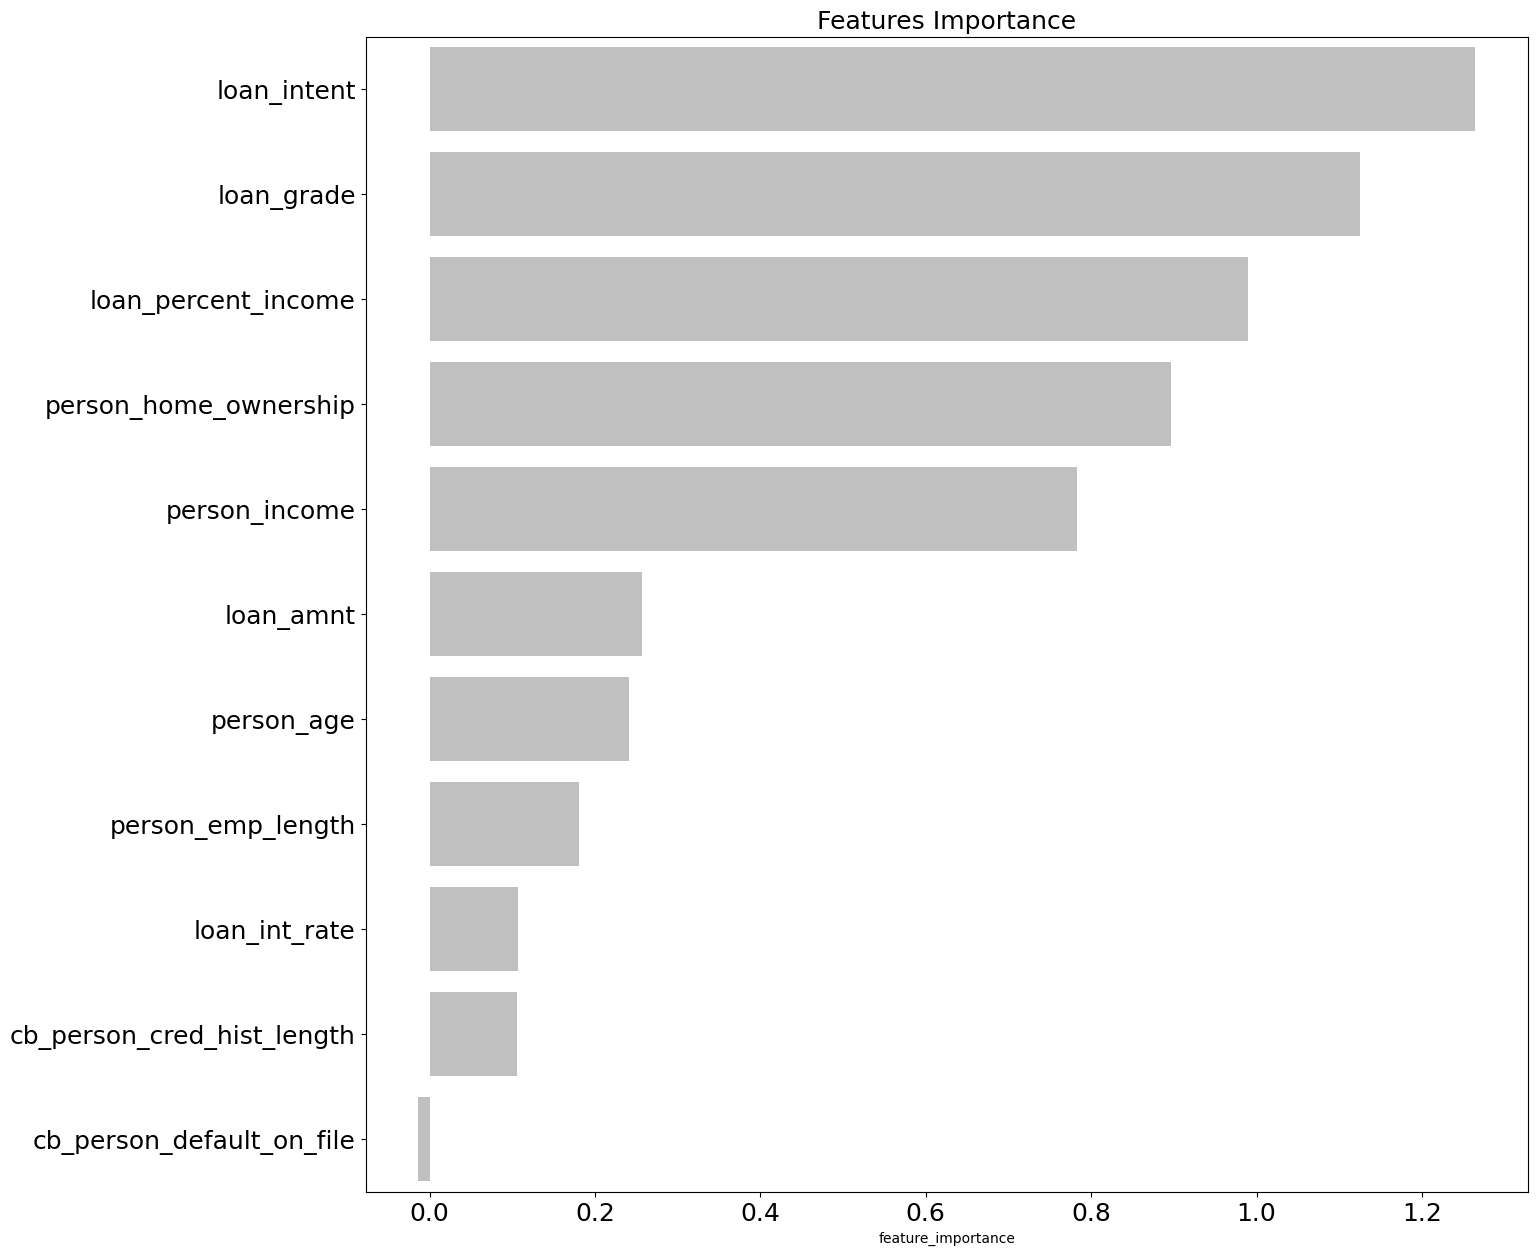

In [38]:
importance = logit_model.coef_[0]
feat_importances_1 = pd.Series(importance, index=WOE_dict.keys())
feat_importances_1=pd.DataFrame(feat_importances_1).reset_index()
feat_importances_1.columns=['feature_name','feature_importance']
feat_importances_1=feat_importances_1.sort_values(['feature_importance'],ascending=False)
# plot feature importance
plt.figure(figsize=(15,15))
sns_plot2=sns.barplot(x=feat_importances_1.feature_importance,y=feat_importances_1.feature_name,estimator=sum, color='silver')
plt.title("Features Importance",size=18)
plt.ylabel('', size = 15)
plt.tick_params(labelsize=18)
print(feat_importances_1)

In [39]:
print(importance)

[ 0.24097154  0.78232464  0.18109566  0.25654585  0.10656717  0.1055186
  0.98936432  0.8964433   1.26442244  1.12538609 -0.01345233]


In [ ]:
# ROC Curve in test set

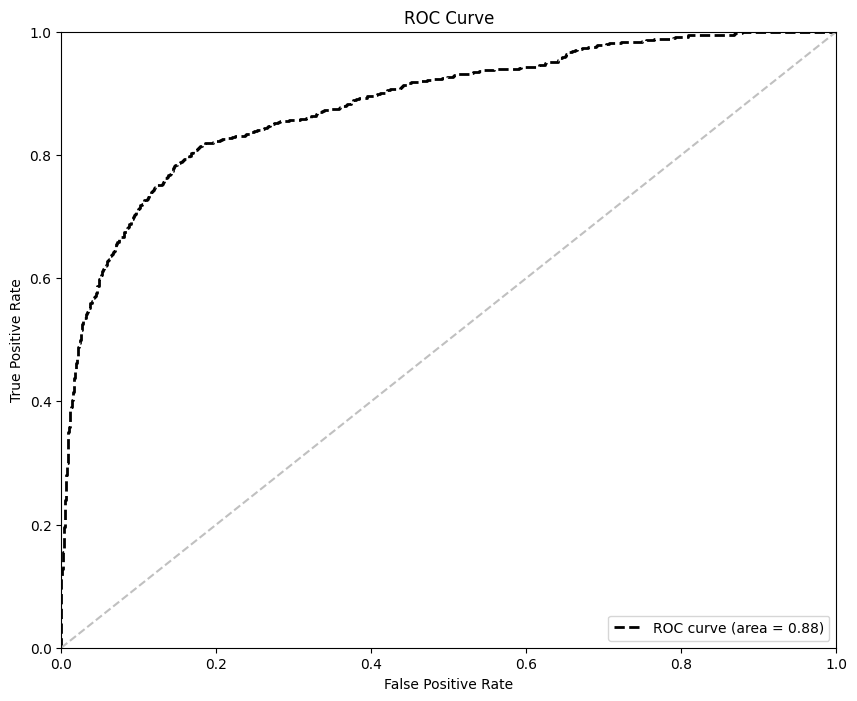

In [40]:
from sklearn.metrics import roc_curve, auc

y_pred_prob_test = logit_model.predict_proba(X_test)[:, 1]
fpr, tpr, thres = roc_curve(y_test, y_pred_prob_test)
roc_auc = auc(fpr, tpr)

def _plot_roc_curve(fpr, tpr, thres, auc):
    plt.figure(figsize = (10, 8))
    plt.plot(fpr, tpr, 'b-', color='black', lw=2, linestyle='--', label='ROC curve (area = %0.2f)'%auc)
    plt.plot([0, 1], [0, 1], '--', color='silver')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.title('ROC Curve')

_plot_roc_curve(fpr, tpr, thres, roc_auc)

In [ ]:
# Precision and recall in test set

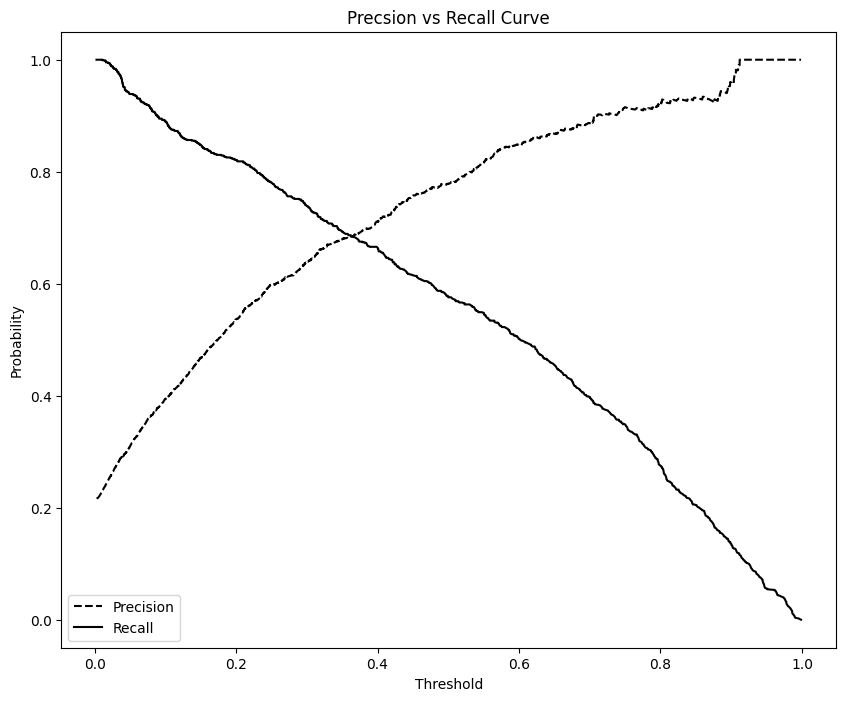

In [41]:
from sklearn.metrics import precision_recall_curve
precision, recall, thres = precision_recall_curve(y_test, y_pred_prob_test)

def _plot_prec_rec_curve(prec, rec, thres):
    plt.figure(figsize = (10, 8))
    plt.plot(thres, prec[:-1], 'k--', label = 'Precision')
    plt.plot(thres, rec[:-1], 'k-', label = 'Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Probability')
    plt.title('Precsion vs Recall Curve')
    plt.legend()

_plot_prec_rec_curve(precision, recall, thres)

In [ ]:
# Kolmogorov-Smirnov test

In [42]:
def _KM(y_pred, n_bins):
    _, thresholds = pd.qcut(y_pred, q=n_bins, retbins=True)
    cmd_BAD = []
    cmd_GOOD = []
    BAD_id = set(np.where(y_test == 0)[0])
    GOOD_id = set(np.where(y_test == 1)[0])
    total_BAD = len(BAD_id)
    total_GOOD = len(GOOD_id)
    for thres in thresholds:
        pred_id = set(np.where(y_pred <= thres)[0])

        per_BAD = len(pred_id.intersection(BAD_id))/total_BAD
        cmd_BAD.append(per_BAD)

        per_GOOD = len(pred_id.intersection(GOOD_id))/total_GOOD
        cmd_GOOD.append(per_GOOD)
    cmd_BAD = np.array(cmd_BAD)
    cmd_GOOD = np.array(cmd_GOOD)
    return cmd_BAD, cmd_GOOD, thresholds

cmd_BAD, cmd_GOOD, thresholds = _KM(y_pred_prob_test, n_bins=20)

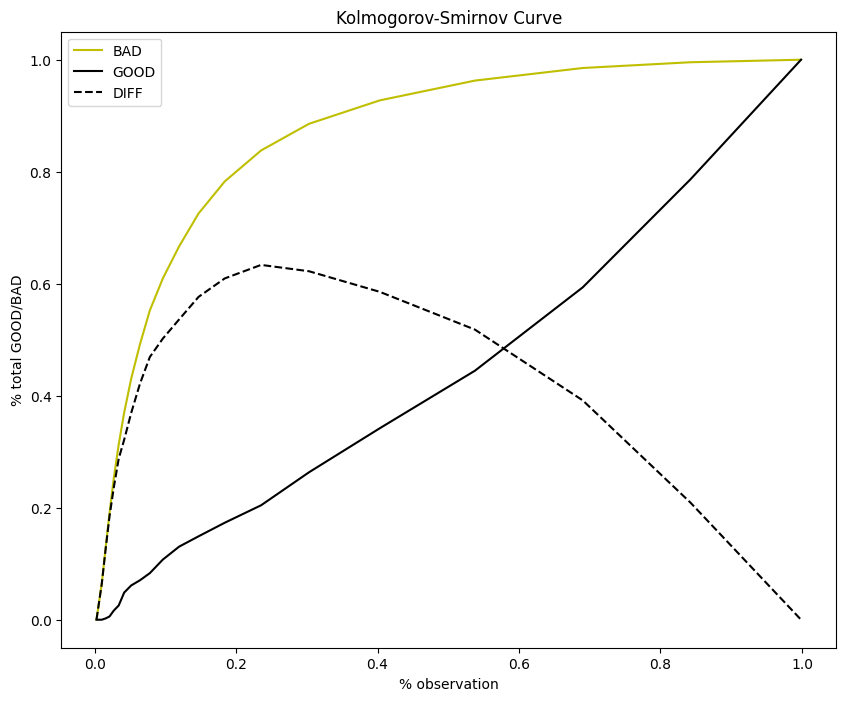

In [43]:
def _plot_KM(cmd_BAD, cmd_GOOD, thresholds):
    plt.figure(figsize = (10, 8))
    plt.plot(thresholds, cmd_BAD, 'y-', label = 'BAD')
    plt.plot(thresholds, cmd_GOOD, 'k-', label = 'GOOD')
    plt.plot(thresholds, cmd_BAD-cmd_GOOD, 'k--', label = 'DIFF')
    plt.xlabel('% observation')
    plt.ylabel('% total GOOD/BAD')
    plt.title('Kolmogorov-Smirnov Curve')
    plt.legend()

_plot_KM(cmd_BAD, cmd_GOOD, thresholds)

In [44]:
from scipy import stats

stats.ks_2samp(cmd_BAD, cmd_GOOD)


KstestResult(statistic=np.float64(0.5238095238095238), pvalue=np.float64(0.005467427576534314), statistic_location=np.float64(0.20438799076212472), statistic_sign=np.int8(-1))

In [ ]:
# AdaBoost Model

True Positive： 506
True Negative： 2958
False Positive： 153
False Negative： 360
accuracy:  0.8710082977118431
（recall）:  0.5842956120092379
（precision）:  0.7678300455235205
F1 score:  0.6636065573770491
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3111
           1       0.77      0.58      0.66       866

    accuracy                           0.87      3977
   macro avg       0.83      0.77      0.79      3977
weighted avg       0.86      0.87      0.86      3977

balanced_accuracy_score:  0.7675576420701926
                  feature_name  feature_importance
9                   loan_grade            0.359887
6          loan_percent_income            0.265612
7        person_home_ownership            0.150932
1                person_income            0.108384
8                  loan_intent            0.066817
4                loan_int_rate            0.024763
3                    loan_amnt            0.010263
0                 

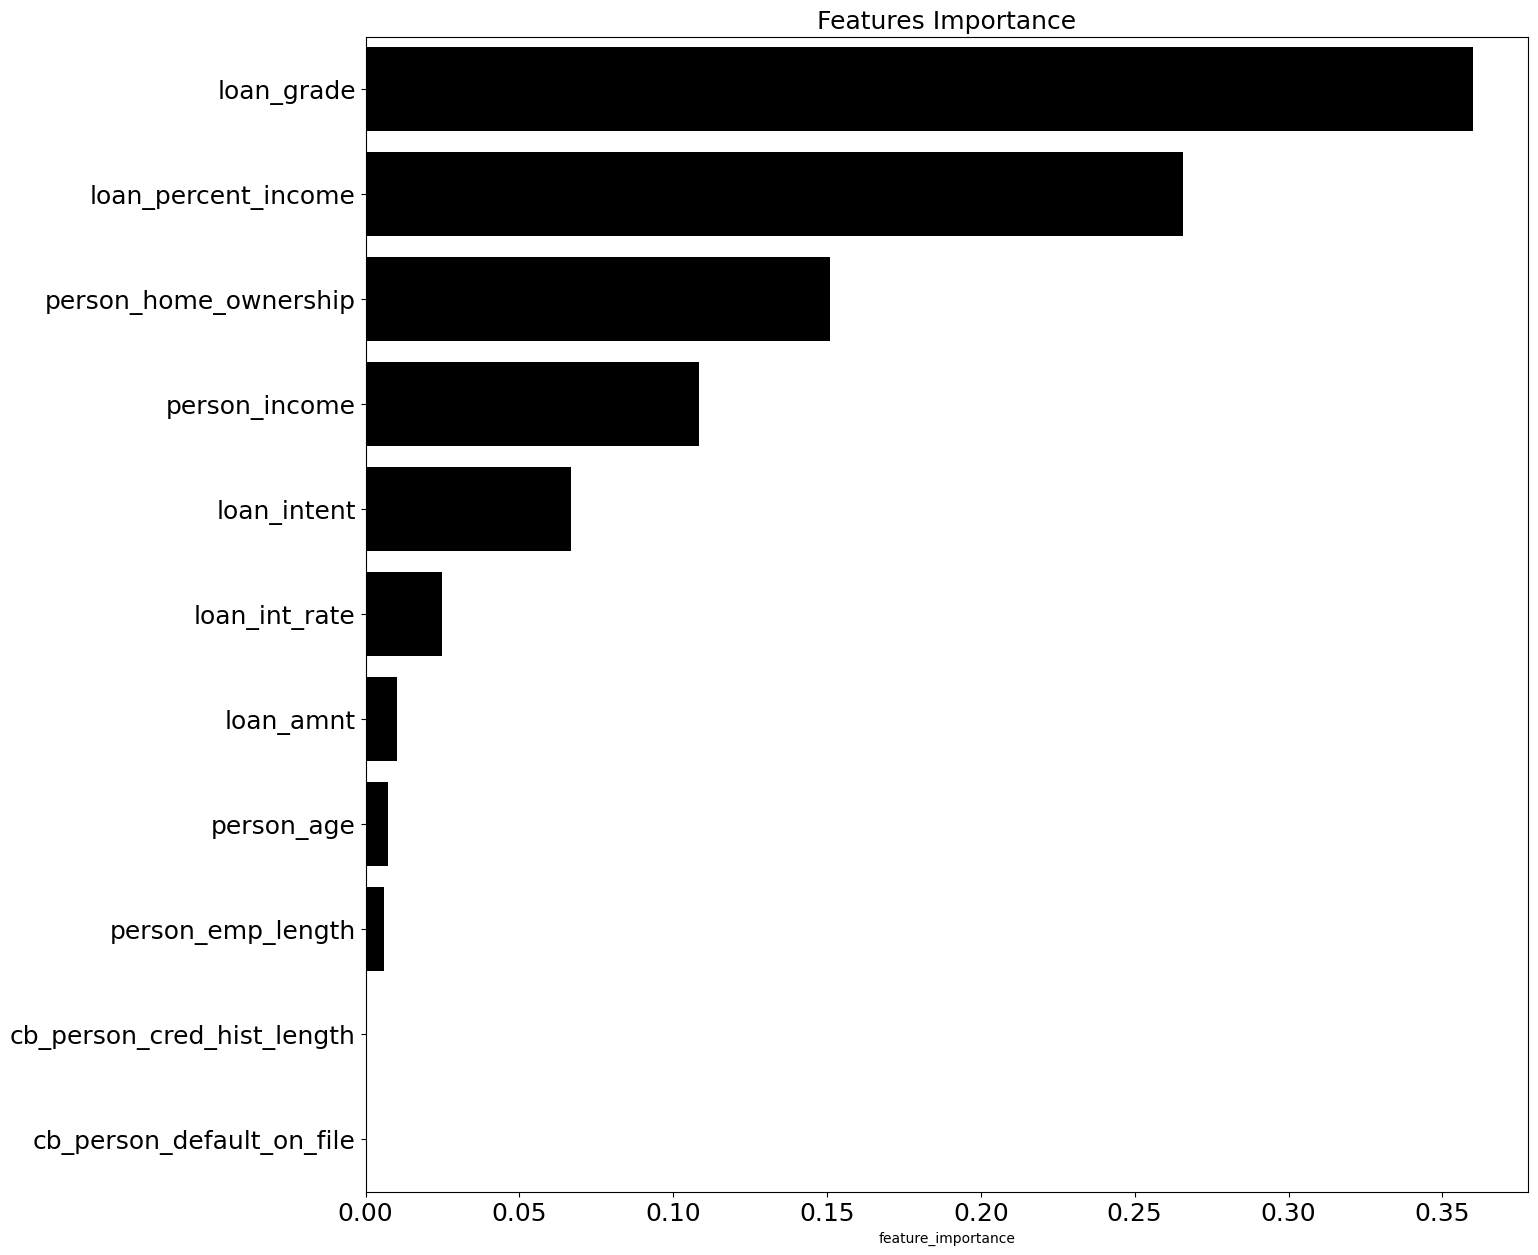

In [45]:
model = AdaBoostClassifier(n_estimators=150,random_state=0)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
get_evaluation_scores(label = y_test, predictions=predictions)
feat_importances = pd.Series(model.feature_importances_, index=WOE_dict.keys())
feat_importances=pd.DataFrame(feat_importances).reset_index()
feat_importances.columns=['feature_name','feature_importance']
feat_importances=feat_importances.sort_values(['feature_importance'],ascending=False)


plt.figure(figsize=(15,15))
sns_plot1=sns.barplot(x=feat_importances.feature_importance,y=feat_importances.feature_name,estimator=sum, color='black')
plt.title("Features Importance",size=18)
plt.ylabel('', size = 15)
plt.tick_params(labelsize=18)

print(feat_importances)
#fet_importance_GBDT_reason,model,x_train,y_train,x_test,y_test = evaluate_result(df_train=train_woe,df_test=test_woe,features_name=features_use)

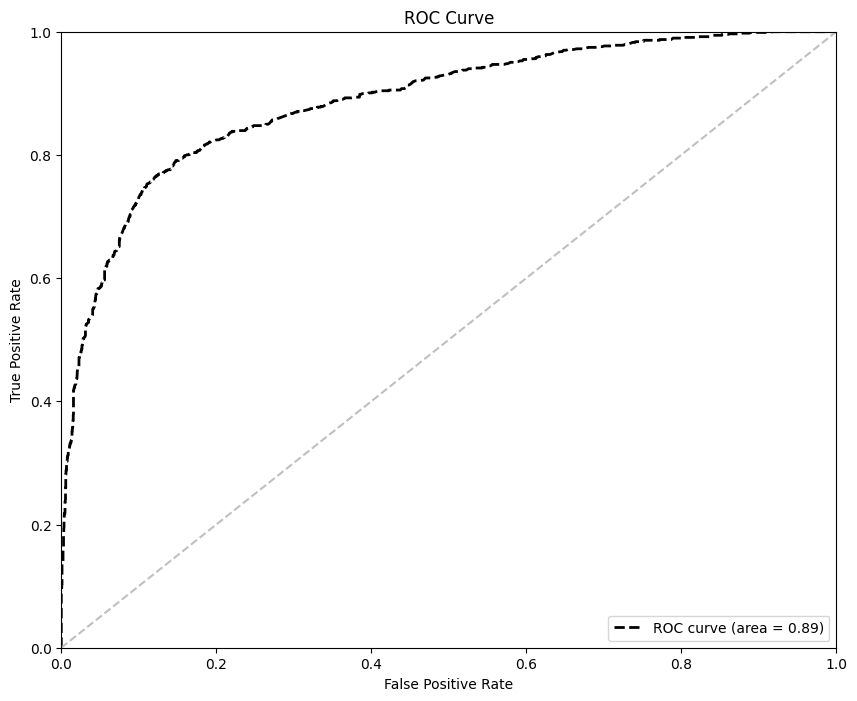

In [46]:
y_pred_prob_test_1 = model.predict_proba(X_test)[:, 1]
fpr_1, tpr_1, thres_1 = roc_curve(y_test, y_pred_prob_test_1)
roc_auc_1 = auc(fpr_1, tpr_1)

def _plot_roc_curve(fpr, tpr, thres, auc):
    plt.figure(figsize = (10, 8))
    plt.plot(fpr, tpr, 'b-', color='black', lw=2, linestyle='--', label='ROC curve (area = %0.2f)'%auc)
    plt.plot([0, 1], [0, 1], '--', color='silver')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.title('ROC Curve')

_plot_roc_curve(fpr_1, tpr_1, thres_1, roc_auc_1)

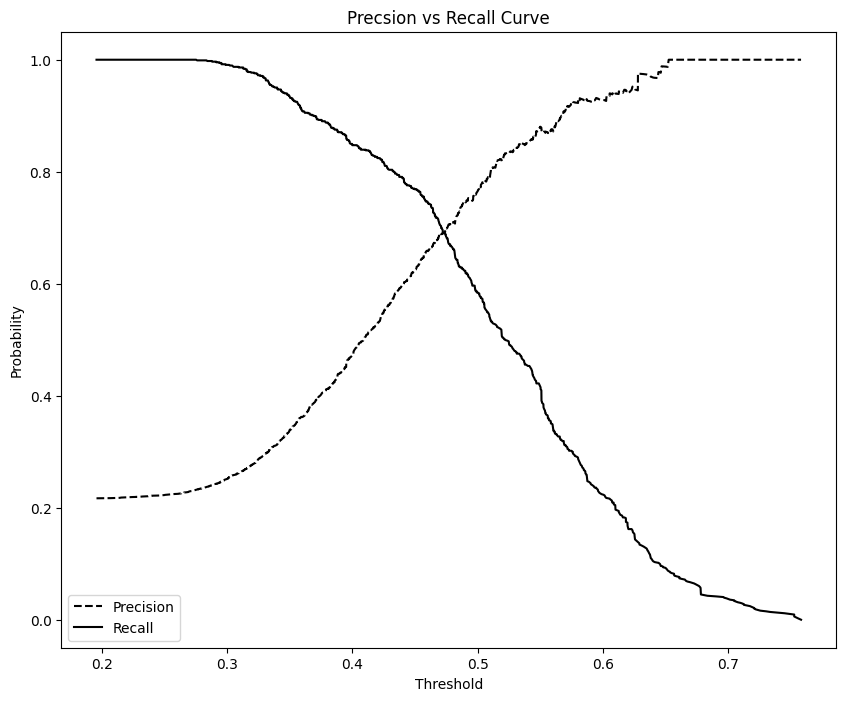

In [47]:
from sklearn.metrics import precision_recall_curve

y_pred_proba_test_1 = model.predict_proba(X_test)[:, 1]
precision, recall, thres = precision_recall_curve(y_test, y_pred_proba_test_1)

def _plot_prec_rec_curve(prec, rec, thres):
    plt.figure(figsize = (10, 8))
    plt.plot(thres, prec[:-1], 'k--', label = 'Precision')
    plt.plot(thres, rec[:-1], 'k-', label = 'Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Probability')
    plt.title('Precsion vs Recall Curve')
    plt.legend()

_plot_prec_rec_curve(precision, recall, thres)

In [ ]:
# Credit score for each feature

In [48]:
def _CreditScore(beta, alpha, woe, n = 12, odds = 1/4, pdo = -50, thres_score = 600):
    factor = pdo/np.log(2)
    offset = thres_score - factor*np.log(odds)
    score = (beta*woe+alpha/n)*factor+offset/n
    return score

_CreditScore(beta = 0.5, alpha = -1, woe = 0.15, n = 12)

np.float64(42.2677896003704)

In [49]:
# alpha and beta

In [50]:
betas_dict = dict(zip(list(X_train.columns), logit_model.coef_[0]))
alpha = logit_model.intercept_[0]
betas_dict

{'person_age_WOE': np.float64(0.2409715448445446),
 'person_income_WOE': np.float64(0.7823246446541807),
 'person_emp_length_WOE': np.float64(0.18109565907602987),
 'loan_amnt_WOE': np.float64(0.2565458494266885),
 'loan_int_rate_WOE': np.float64(0.10656716949234249),
 'cb_person_cred_hist_length_WOE': np.float64(0.10551859853610655),
 'loan_percent_income_WOE': np.float64(0.9893643212452715),
 'person_home_ownership_WOE': np.float64(0.8964432994854652),
 'loan_intent_WOE': np.float64(1.2644224373624349),
 'loan_grade_WOE': np.float64(1.1253860873540025),
 'cb_person_default_on_file_WOE': np.float64(-0.013452333678026031)}

In [51]:
alpha

np.float64(-1.3492147871096354)

In [ ]:
# WOE for each feature

In [52]:
cols = []
features = []
woes = []
betas = []
scores = []

for col in columns:
    for feature, woe in WOE_dict[col]['table']['WOE'].to_frame().iterrows():
        cols.append(col)
        # Add feature
        feature = str(feature)
        features.append(feature)
        # Add woe
        woe = woe.values[0]
        woes.append(woe)
        # Add beta
        col_woe = col+'_WOE'
        beta = betas_dict[col_woe]
        betas.append(beta)
        # Add score
        score = _CreditScore(beta = beta, alpha = alpha, woe = woe, n = 12)
        scores.append(score)

df_WOE = pd.DataFrame({'Columns': cols, 'Features': features, 'WOE': woes, 'Betas':betas, 'Scores':scores})
df_WOE.head()

,Columns,Features,WOE,Betas,Scores
0,person_age,"(-999999999.0, 22.0]",0.271586,0.240972,45.056286
1,person_age,"(22.0, 23.0]",-0.018387,0.240972,50.096721
2,person_age,"(23.0, 24.0]",0.034689,0.240972,49.174133
3,person_age,"(24.0, 25.0]",-0.001281,0.240972,49.799376
4,person_age,"(25.0, 26.0]",-0.143529,0.240972,52.271994


In [53]:
test_obs = data[columns].iloc[0:1, :]
test_obs

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,25,72000,MORTGAGE,4.784432,HOMEIMPROVEMENT,A,2000,7.66,0.03,N,4


In [55]:
def _search_score(obs, col):
    feature = [str(inter) for inter in list(WOE_dict[col]['table'].index) if obs[col].values[0] in inter][0]
    score = df_WOE[(df_WOE['Columns'] == col) & (df_WOE['Features'] == feature)]['Scores'].values[0]
    return score


score = _search_score(test_obs, 'loan_amnt')
score

np.float64(50.170207458375515)

### Score for each feature in data

In [56]:
def _total_score(obs, columns = columns):
    scores = dict()
    for col in columns:
        scores[col] = _search_score(obs, col)
    total_score = sum(scores.values())
    return scores, total_score

scores, total_score = _total_score(test_obs)
print('score for each fields: \n', scores)
print('final total score: ', total_score)

score for each fields: 
 {'person_age': np.float64(49.79937570027304), 'person_income': np.float64(73.36889841221203), 'person_home_ownership': np.float64(92.18153715104829), 'person_emp_length': np.float64(49.9256866292544), 'loan_intent': np.float64(30.607785957717724), 'loan_grade': np.float64(122.0464523521604), 'loan_amnt': np.float64(50.170207458375515), 'loan_int_rate': np.float64(57.413533867045075), 'loan_percent_income': np.float64(112.39326074131498), 'cb_person_default_on_file': np.float64(49.56325168702932), 'cb_person_cred_hist_length': np.float64(49.39057194940554)}
final total score:  736.8605619058362


In [57]:
scores_table_final = pd.DataFrame.from_dict([scores]).T.reset_index()

In [58]:
scores_table_final.columns = ['Features', 'Credit Score']

In [59]:
scores_table_final

,Features,Credit Score
0,person_age,49.799376
1,person_income,73.368898
2,person_home_ownership,92.181537
3,person_emp_length,49.925687
4,loan_intent,30.607786
5,loan_grade,122.046452
6,loan_amnt,50.170207
7,loan_int_rate,57.413534
8,loan_percent_income,112.393261
9,cb_person_default_on_file,49.563252


In [ ]:
# Score for all data

In [60]:
total_scores = []
for i in np.arange(data[columns].shape[0]):
    obs = data[columns].iloc[i:(i+1), :]
    _, score = _total_score(obs)
    total_scores.append(score)
data['Score'] = total_scores

In [61]:
data.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,person_emp_length_WOE,loan_amnt_WOE,loan_int_rate_WOE,cb_person_cred_hist_length_WOE,loan_percent_income_WOE,person_home_ownership_WOE,loan_intent_WOE,loan_grade_WOE,cb_person_default_on_file_WOE,Score
0,25,72000,MORTGAGE,4.784432,HOMEIMPROVEMENT,A,2000,7.660000,0,0.03,...,-0.011374,-0.021242,-0.993396,0.050783,-0.877376,-0.655758,0.210170,-0.890242,-0.220382,736.860562
1,26,32000,RENT,4.000000,DEBTCONSOLIDATION,A,12250,11.016532,1,0.38,...,-0.011374,0.138649,-0.183039,0.068992,2.168064,0.503276,0.376072,-0.890242,-0.220382,346.508059
2,25,34000,MORTGAGE,2.000000,HOMEIMPROVEMENT,C,5800,13.480000,1,0.17,...,0.079446,-0.424418,-0.036013,0.068992,-0.281458,-0.655758,0.210170,-0.067700,0.801479,551.253740
3,25,118000,MORTGAGE,8.000000,HOMEIMPROVEMENT,A,15000,7.880000,0,0.13,...,-0.193215,0.332900,-0.575686,0.050783,-0.632246,-0.655758,0.210170,-0.890242,-0.220382,744.260750
4,22,96000,MORTGAGE,6.000000,EDUCATION,C,6000,13.490000,0,0.06,...,-0.193215,-0.424418,-0.036013,0.068992,-0.664628,-0.655758,-0.329343,-0.067700,-0.220382,735.593426


Text(0.5, 1.0, 'Distribution Score in Default vs Non-Default')

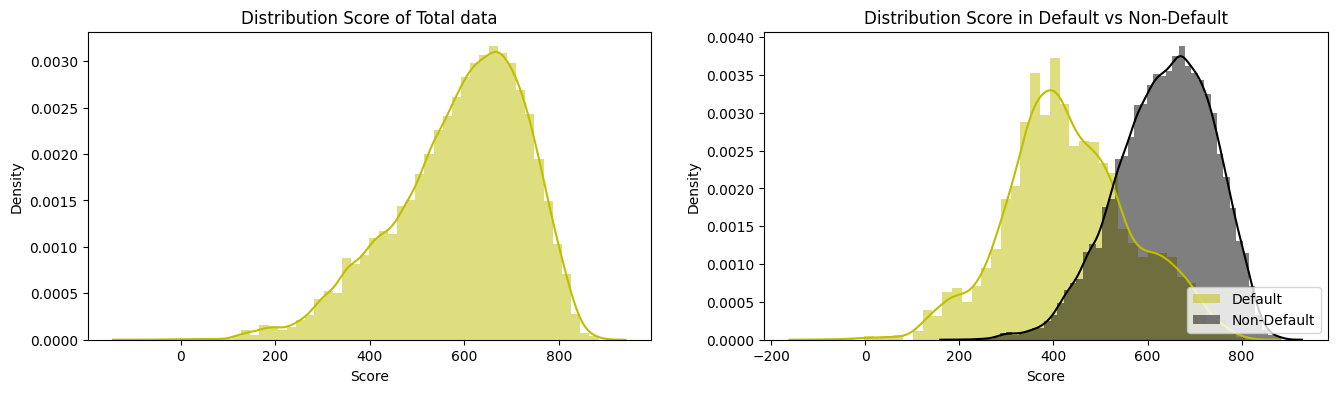

In [62]:
plt.figure(figsize=(16, 4))
plt.subplot(121)
sns.distplot(data['Score'], kde_kws={"color": "y"},
             hist_kws={"color": "y", "alpha":0.5})
plt.title('Distribution Score of Total data')
plt.subplot(122)
sns.distplot(data[data['loan_status']==1]['Score'], label='Default', kde_kws={"color": "y"},
             hist_kws={"color": "y", "alpha":0.5})
sns.distplot(data[data['loan_status']==0]['Score'], label='Non-Default',
             kde_kws={"color": "k"},
             hist_kws={"color": "k", "alpha":0.5})
plt.legend(loc = 'lower right')
plt.title('Distribution Score in Default vs Non-Default')